In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from yaolib import plot_image
from yaolib.cmaps import turbo_w

%matplotlib widget

# Structure

(-21.910442715746296, 21.910442715746296, -22.525, 22.025)

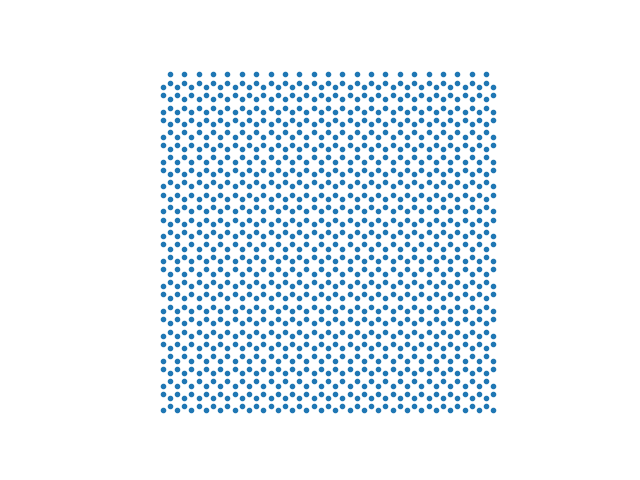

In [2]:
nmax = 20.
lattice = []
for x in np.arange(-nmax*2,nmax*2+1e-3):
    ys = np.arange(-nmax,nmax+1e-3)
    if abs(np.sqrt(3)*x/2)<=nmax:
        if np.mod(x,2)==0:
            choose = np.mod(ys,3)>=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]])
        else:
            choose = np.mod(ys,3)<=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]-1/2])
lattice = np.hstack(lattice).T

fig, ax = plt.subplots()
ax.plot(lattice[:,0], lattice[:,1], '.')
ax.set_aspect('equal')
ax.axis('off')

In [3]:
Qx, Qy = np.arange(-1.5,1.5+1e-5,0.01), np.arange(-1.5,1.5+1e-5,0.01)
Qxx, Qyy = np.meshgrid(Qx, Qy)
Qxx = np.tile(Qxx[:,:,np.newaxis], (1,1,lattice.shape[0]))
Qyy = np.tile(Qyy[:,:,np.newaxis], (1,1,lattice.shape[0]))
Rxx = np.tile(lattice[np.newaxis,np.newaxis,:,0], (Qyy.shape[0],Qyy.shape[1],1))
Ryy = np.tile(lattice[np.newaxis,np.newaxis,:,1], (Qyy.shape[0],Qyy.shape[1],1))

In [4]:
SF = np.sum(np.exp(1j*2.*np.pi*(Qxx*Rxx+Qyy*Ryy)), axis=2)
I = np.abs(SF)**2

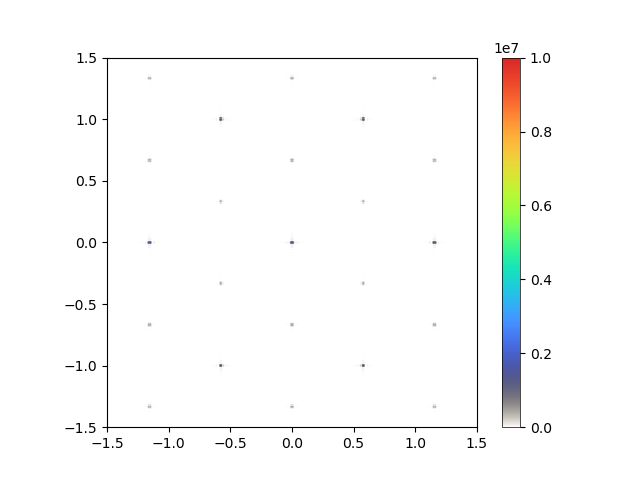

In [5]:
ax, art, cart = plot_image(I, cbar=True, x=Qx, y=Qy, vmin=0, vmax=1e7, cmap=turbo_w())
# for xx in np.arange(-4.,4.1):
#     ax.axvline(x=xx*np.sqrt(3)/3, color='k', ls='--', lw=0.5)
# for xx in np.arange(-5,5.1):
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [-2.5+xx*2/3,2.5+xx*2/3], color='k', ls='--', lw=0.5)
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [2.5+xx*2/3,-2.5+xx*2/3], color='k', ls='--', lw=0.5)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')

# Magnetic structure factor

In [6]:
nmax = 20.
lattice = []
for x in np.arange(-nmax*2,nmax*2+1e-3):
    ys = np.arange(-nmax,nmax+1e-3)
    if abs(np.sqrt(3)*x/2)<=nmax:
        if np.mod(x,2)==0:
            choose = np.mod(ys,3)>=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]])
        else:
            choose = np.mod(ys,3)<=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]-1/2])
lattice = np.hstack(lattice)

spins = lattice[0] + np.nan
for y in np.arange(nmax*-3.,nmax*3.+1e-3,3.):
    choose = np.logical_and(lattice[1]>=y, lattice[1]<=y+1.5)
    spins[choose] = 1.
    choose = np.logical_and(lattice[1]>=y+1.5, lattice[1]<=y+3.)
    spins[choose] = -1.

In [7]:
np.save('honeycomb.npy', np.vstack([lattice,spins]))

(-21.910442715746296, 21.910442715746296, -22.525, 22.025)

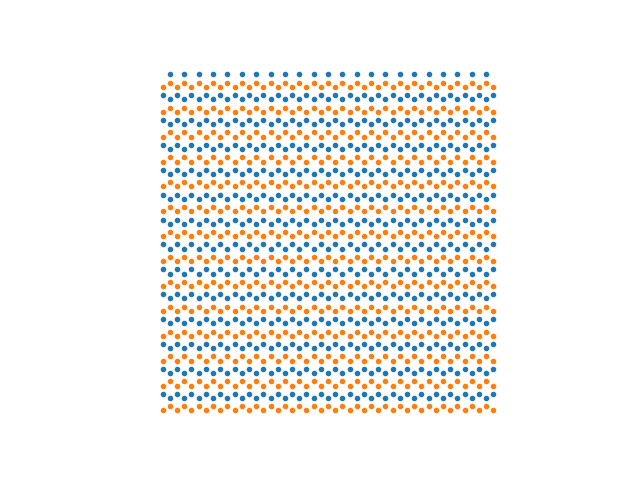

In [8]:
fig, ax = plt.subplots()
choose = spins<=0
ax.plot(lattice[0,choose], lattice[1,choose], '.')
choose = spins>0
ax.plot(lattice[0,choose], lattice[1,choose], '.')
ax.set_aspect('equal')
ax.axis('off')

## colormap

In [9]:
Qx, Qy = np.arange(-1.5,1.5+1e-5,0.01), np.arange(-1.5,1.5+1e-5,0.01)
Qxx, Qyy = np.meshgrid(Qx, Qy)
Qxx = np.tile(Qxx[:,:,np.newaxis], (1,1,lattice.shape[1]))
Qyy = np.tile(Qyy[:,:,np.newaxis], (1,1,lattice.shape[1]))
Rxx = np.tile(lattice[np.newaxis,np.newaxis,0,:], (Qyy.shape[0],Qyy.shape[1],1))
Ryy = np.tile(lattice[np.newaxis,np.newaxis,1,:], (Qyy.shape[0],Qyy.shape[1],1))
Sxy = np.tile(spins[np.newaxis,np.newaxis,:], (Qyy.shape[0],Qyy.shape[1],1))

In [10]:
MSF = np.sum(Sxy*np.exp(1j*2.*np.pi*(Qxx*Rxx+Qyy*Ryy)), axis=2)
I = np.abs(MSF)**2

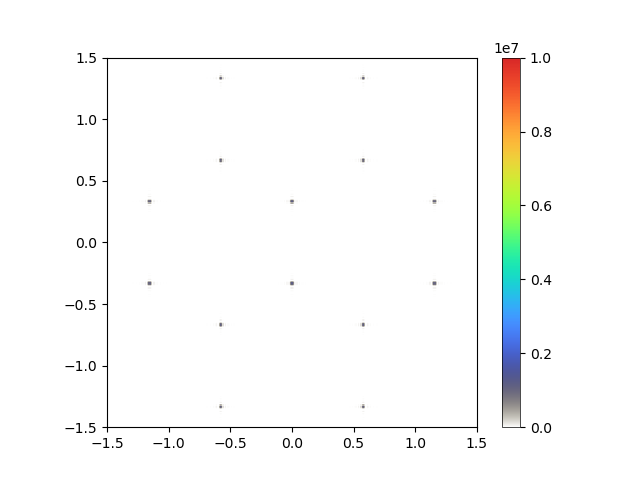

In [11]:
ax, art, cart = plot_image(I, cbar=True, x=Qx, y=Qy, vmin=0, vmax=1e7, cmap=turbo_w())
# for xx in np.arange(-4.,4.1):
#     ax.axvline(x=xx*np.sqrt(3)/3, color='k', ls='--', lw=0.5)
# for xx in np.arange(-5,5.1):
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [-2.5+xx*2/3,2.5+xx*2/3], color='k', ls='--', lw=0.5)
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [2.5+xx*2/3,-2.5+xx*2/3], color='k', ls='--', lw=0.5)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')

## line cut

In [12]:
Qy = np.arange(0.,2./3.+1e-8,0.001)
Qyy = np.tile(Qy[:,np.newaxis], (1,lattice.shape[1]))
Qxx = Qyy * 0.
Rxx = np.tile(lattice[np.newaxis,0,:], (Qy.size,1))
Ryy = np.tile(lattice[np.newaxis,1,:], (Qy.size,1))
Sxy = np.tile(spins[np.newaxis,:], (Qy.size,1))

In [13]:
MSF = np.sum(Sxy*np.exp(1j*2.*np.pi*(Qxx*Rxx+Qyy*Ryy)), axis=1)
I = np.abs(MSF)**2 / lattice.shape[1]

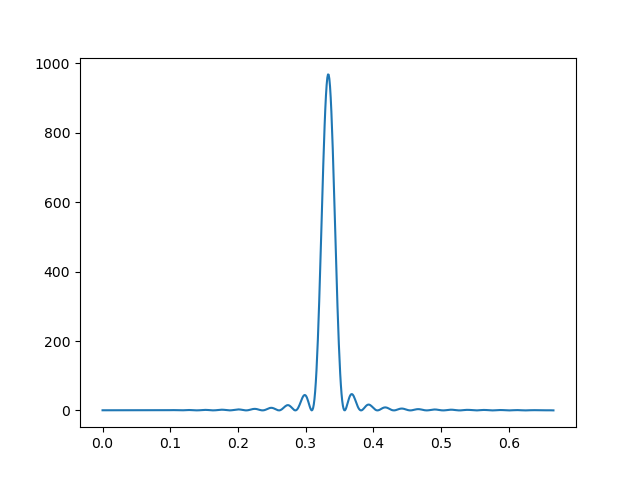

In [14]:
fig, ax = plt.subplots()
ax.plot(Qy, I)

In [15]:
np.savez('I_honeycomb.npz', Krlu=Qy*3., Hrlu=0., I=I)

# High entropy

In [16]:
nmax = 20.
lattice = []
for x in np.arange(-nmax*2,nmax*2+1e-3):
    ys = np.arange(-nmax,nmax+1e-3)
    if abs(np.sqrt(3)*x/2)<=nmax:
        if np.mod(x,2)==0:
            choose = np.mod(ys,3)>=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]])
        else:
            choose = np.mod(ys,3)<=1
            lattice.append([ys[choose]-ys[choose]+x*np.sqrt(3)/2,ys[choose]-1/2])
lattice = np.hstack(lattice)

spins = lattice[0] + np.nan
for y in np.arange(nmax*-3.,nmax*3.+1e-3,3.):
    choose = np.logical_and(lattice[1]>=y, lattice[1]<=y+1.5)
    spins[choose] = 1.
    choose = np.logical_and(lattice[1]>=y+1.5, lattice[1]<=y+3.)
    spins[choose] = -1.
choose = np.random.randint(1,5,spins.size)
spins = spins * choose

In [17]:
np.save('honeycomb_HE.npy', np.vstack([lattice,spins]))

(-21.910442715746296, 21.910442715746296, -22.525, 22.025)

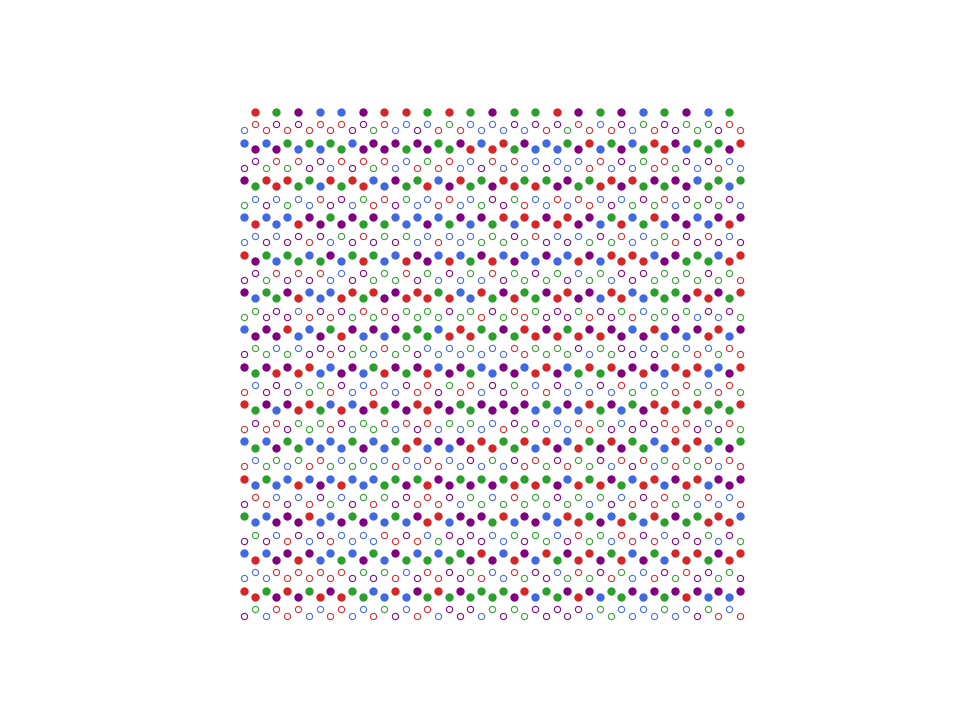

In [18]:
fig, ax = plt.subplots(dpi=150)
choose = spins<-3.5
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='purple')
choose = spins>3.5
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='purple', mfc='w', mew=0.5)
choose = np.logical_and(spins>-3.5, spins<-2.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='C3')
choose = np.logical_and(spins>2.5, spins<3.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='C3', mfc='w', mew=0.5)
choose = np.logical_and(spins>-2.5, spins<-1.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='royalblue')
choose = np.logical_and(spins>1.5, spins<2.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='royalblue', mfc='w', mew=0.5)
choose = np.logical_and(spins>-1.5, spins<-0.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='C2')
choose = np.logical_and(spins>0.5, spins<1.5)
ax.plot(lattice[0,choose], lattice[1,choose], '.', color='C2', mfc='w', mew=0.5)
ax.set_aspect('equal')
ax.axis('off')

## colormap

In [19]:
Qx, Qy = np.arange(-1.5,1.5+1e-5,0.01), np.arange(-1.5,1.5+1e-5,0.01)
Qxx, Qyy = np.meshgrid(Qx, Qy)
Qxx = np.tile(Qxx[:,:,np.newaxis], (1,1,lattice.shape[1]))
Qyy = np.tile(Qyy[:,:,np.newaxis], (1,1,lattice.shape[1]))
Rxx = np.tile(lattice[np.newaxis,np.newaxis,0,:], (Qyy.shape[0],Qyy.shape[1],1))
Ryy = np.tile(lattice[np.newaxis,np.newaxis,1,:], (Qyy.shape[0],Qyy.shape[1],1))
Sxy = np.tile(spins[np.newaxis,np.newaxis,:], (Qyy.shape[0],Qyy.shape[1],1))
choose = np.logical_and(np.abs(Sxy)>0.5, np.abs(Sxy)<1.5)
Sxy[~choose] = 0.

In [20]:
MSF = np.sum(Sxy*np.exp(1j*2.*np.pi*(Qxx*Rxx+Qyy*Ryy)), axis=2)
I = np.abs(MSF)**2

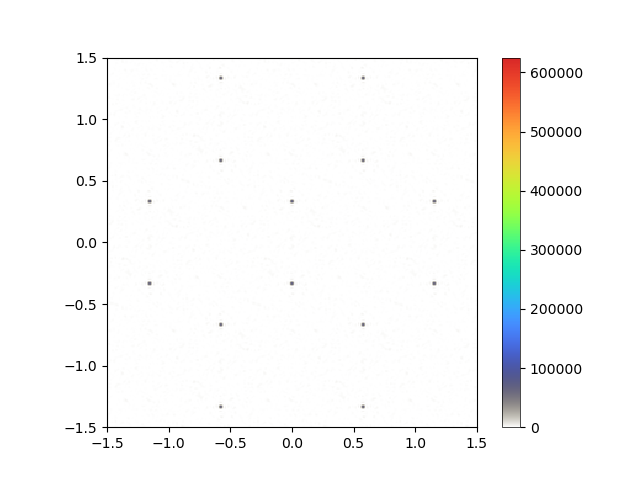

In [21]:
ax, art, cart = plot_image(I, cbar=True, x=Qx, y=Qy, vmin=0, vmax=1e7/16, cmap=turbo_w())
# for xx in np.arange(-4.,4.1):
#     ax.axvline(x=xx*np.sqrt(3)/3, color='k', ls='--', lw=0.5)
# for xx in np.arange(-5,5.1):
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [-2.5+xx*2/3,2.5+xx*2/3], color='k', ls='--', lw=0.5)
#     ax.plot([-2.5*np.sqrt(3),2.5*np.sqrt(3)], [2.5+xx*2/3,-2.5+xx*2/3], color='k', ls='--', lw=0.5)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')

## line cut

In [22]:
Qy = np.arange(0.,2./3.+1e-8,0.001)
Qyy = np.tile(Qy[:,np.newaxis], (1,lattice.shape[1]))
Qxx = Qyy * 0.
Rxx = np.tile(lattice[np.newaxis,0,:], (Qy.size,1))
Ryy = np.tile(lattice[np.newaxis,1,:], (Qy.size,1))
Sxy = np.tile(spins[np.newaxis,:], (Qy.size,1))
choose = np.logical_and(np.abs(Sxy)>0.5, np.abs(Sxy)<1.5)
Sxy[~choose] = 0.

In [23]:
MSF = np.sum(Sxy*np.exp(1j*2.*np.pi*(Qxx*Rxx+Qyy*Ryy)), axis=1)
I = np.abs(MSF)**2 / lattice.shape[1]

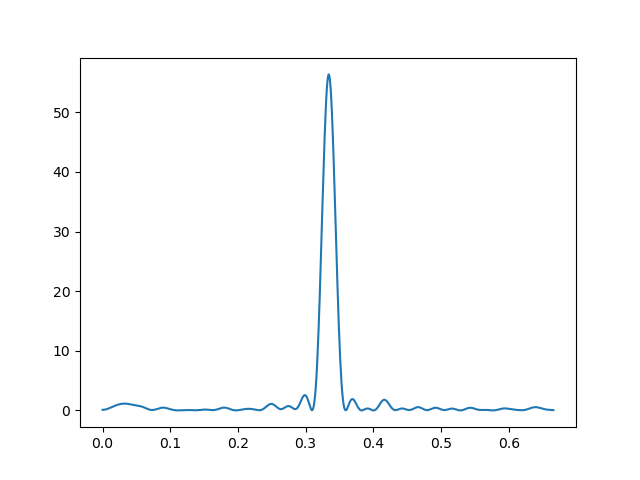

In [24]:
fig, ax = plt.subplots()
ax.plot(Qy, I)

In [25]:
np.savez('I_honeycomb_HE.npz', Krlu=Qy*3., Hrlu=0., I=I)